## <center> Dr.Semmelweis and the Importance of Handwashing <center>

In [48]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [49]:
# Import 'yearly_deaths_by_clinic.csv' dataset
yearly_deaths = pd.read_csv('datasets/yearly_deaths_by_clinic.csv')
# Display the first five rows of the dataset
yearly_deaths.head()

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1


In [50]:
# Yearly deaths ratio in 'yearly_deaths'
yearly_deaths['deaths_ratio'] = yearly_deaths['deaths'] / (yearly_deaths['births'] + yearly_deaths['deaths'])
yearly_deaths.head()

,year,births,deaths,clinic,deaths_ratio
0,1841,3036,237,clinic 1,0.072411
1,1842,3287,518,clinic 1,0.136137
2,1843,3060,274,clinic 1,0.082184
3,1844,3157,260,clinic 1,0.076090
4,1845,3492,241,clinic 1,0.064559


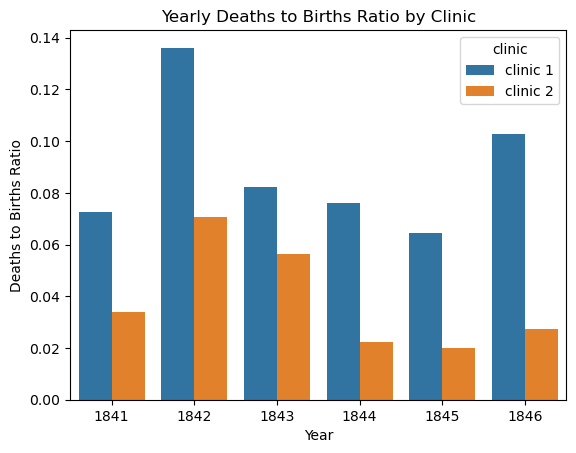

In [51]:
# Create a bar plot for deaths ratio by year and clinic
sns.barplot(data = yearly_deaths, x = 'year', y = 'deaths_ratio', hue = 'clinic')
plt.title('Yearly Deaths to Births Ratio by Clinic')
plt.xlabel('Year')
plt.ylabel('Deaths to Births Ratio')
plt.show()

In [52]:
# What year had the highest yearly proportion of deaths at each clinic?
highest_year = 1842

In [53]:
# Import monthly_deaths_by_clinic.csv dataset
monthly_deaths = pd.read_csv('datasets/monthly_deaths.csv')
monthly_deaths.head()

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2


In [54]:
# Create a handwashing_started column in monthly_deaths dataset
for index, value in monthly_deaths['date'].items():
    if value >= '1847-06-01':
        monthly_deaths.loc[index, 'handwashing_started'] = True
    else:
        monthly_deaths.loc[index, 'handwashing_started'] = False

In [55]:
monthly_deaths.head()

,date,births,deaths,handwashing_started
0,1841-01-01,254,37,False
1,1841-02-01,239,18,False
2,1841-03-01,277,12,False
3,1841-04-01,255,4,False
4,1841-05-01,255,2,False


In [56]:
# Calculate the deaths ratio for each date in the monthly_deaths dataset
monthly_deaths["deaths_ratio"] = monthly_deaths["deaths"] / (monthly_deaths["births"] + monthly_deaths["deaths"])
monthly_deaths.head()

,date,births,deaths,handwashing_started,deaths_ratio
0,1841-01-01,254,37,False,0.127148
1,1841-02-01,239,18,False,0.070039
2,1841-03-01,277,12,False,0.041522
3,1841-04-01,255,4,False,0.015444
4,1841-05-01,255,2,False,0.007782


In [57]:
# Create the monthly_summary dataframe 
monthly_summary = pd.DataFrame(monthly_deaths.groupby('handwashing_started')['deaths_ratio'].mean()).reset_index()
monthly_summary

,handwashing_started,deaths_ratio
0,False,0.091526
1,True,0.020452


In [58]:
# Difference in the mean monthly proportion of deaths before and after the introduction of handwashing using all of the data
